# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           61          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [ ]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

#### Seed

In [ ]:
# We use fixed seed to ensure reproducibility of our results
# NOTE: im not sure if this is what they mean "to ensure reproducibility"
# np.random.seed(10)
# according to tas, the np random is just a collection of random numbers
# so if we retrain the network we will get a different random initial value from the list
# but if we rerun the notebook multiple times over the same seed set, we will get the same results (in plural, as in we will get the same final weights from all the different training runs of the network)
# the convention is seed 42

#### Loading the data

In [ ]:
features = np.genfromtxt("../data/features.txt", delimiter=",") # 7854 samples of 10 features
targets = np.genfromtxt("../data/targets.txt", delimiter=",")   # 7854 target classes of the samples mentioned above
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")   # 784 samples of 10 features, with no lables available

## 1 Questions
### 1.2 Architecture
#### Question 1:

In [ ]:
# Inputs
logic_gates = {
    "AND": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 0, 0, 1]},
    "OR":  {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 1]},
    "XOR": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 0]},
}

# Functions
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of the sigmoid function."""
    s = sigmoid(z)
    return s * (1 - s)

def forward(X, w, b):
    """Forward pass: computes pre-activation z and activation h = sigmoid(z)."""
    z = X @ w + b
    h = sigmoid(z)
    return z, h

def loss(y, h):
    """Mean squared error loss."""
    return np.sum((y - h) ** 2)

def backward(X, y, h, z):
    """Backward pass: computes gradients dw and db using the chain rule."""
    m = X.shape[0]
    dL_dz = -2 * (y - h) * sigmoid_derivative(z)
    dw = (X.T @ dL_dz) / m
    db = np.sum(dL_dz) / m
    return dw, db

def train_perceptron(X, y, epochs=1000, lr=0.1):
    """Trains a single perceptron with sigmoid activation using gradient descent.

    Returns: (w, b, loss_history)
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)

    # Initialize weights and bias
    w = np.random.randn(X.shape[1], 1)
    b = np.random.randn()
    loss_history = []

    # Training loop
    for _ in range(epochs):
        z, h = forward(X, w, b)
        loss_history.append(loss(y, h))
        dw, db = backward(X, y, h, z)
        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

# Train and plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, gate) in enumerate(logic_gates.items()):
    # Train perceptron
    X = np.array(gate["x"], dtype=float)
    y = np.array(gate["y"], dtype=float)
    w, b, losses = train_perceptron(gate["x"], gate["y"])

    # Loss over epochs
    ax_loss = axes[0, col]
    epochs = np.arange(1, len(losses) + 1)
    ax_loss.plot(epochs, losses, color="purple")
    ax_loss.set_title(f"{name} gate loss over epochs")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)

    # Decision boundaries
    ax_decision = axes[1, col]

    # Plot data points
    for i in range(len(y)):
        color = "red" if y[i] == 1 else "blue"
        ax_decision.scatter(X[i, 0], X[i, 1], c=color, s=120, edgecolors="k", zorder=3)

    # Plot decision boundary
    w0, w1 = w.flatten()
    x_line = np.linspace(-0.5, 1.5, 200)
    if abs(w1) > 1e-10:
        ax_decision.plot(x_line, -(w0 * x_line + b) / w1, "k--")
    else:
        ax_decision.axvline(x=-b / w0, color="k", linestyle="--")

    ax_decision.set_xlim(-0.5, 1.5)
    ax_decision.set_ylim(-0.5, 1.5)
    ax_decision.set_xlabel("$x_1$")
    ax_decision.set_ylabel("$x_2$")
    ax_decision.set_title(f"{name} gate decision boundary")
    ax_decision.grid(True)

plt.tight_layout()
plt.show()

For `OR` and `AND` gates the loss curve approaches zero, and the final decision boundary cleanly separates the two classes. This shows that the perceptron successfully learned a linear separator that matches the corresponding truth table.

On the other hand, for the `XOR` gate the loss decreases montonically but plateaus at 1. The final decision boundary fails to separate the opposing classing, showing the `XOR` is not linearly separable, so a single preceptron cannot represent it.

<h4>Question 2: How many input neurons are needed in our classification task as described above? </h4>


The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

<h4>Question 3: How many output neurons do you require?</h4>

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

<h4>Question 4: How many hidden neurons and layers will your network have?

The number of hidden neurons and layers is determined by balancing the dataset complexity, available computational power, and the risk of overfitting. Our dataset consists of 10 meaningful, human-designed features per sample and is of moderate size. Given this, a network with 1 hidden layer is a reasonable starting point, as a second layer would only be needed if the patterns are more complex or hierarchical.

There is no strict formula for choosing the numnber of neurons in a hidden layers, but common heuristics provide guidance. Two widely used rules are the "between the input and output size" rule and the "2/3 rule".

The first suggests a number between the input and output size, in our case that would mean: (input + output)/2 = (10 + 7)/2 ≈ 8 neurons. The 2/3 rule gives (2/3) * input + output = (2/3) * 10 + 7 ≈ 14. These values are usually enough to learn simple patterns, but may not capture more subtle feature interactions.

To provide extra capacity while maintaining computational efficiency, we decided to roughly double the heuristic values, giving 30 neurons. Following standard practice of using powers of 2, we rounded this to 32 neurons.

During experimentation, if the network underfits (fails to learn the patterns), the number of neurons can be increased, and if it overfits (memorises the training data), they can be reduced. A second hidden layer can be added if the network struggles to capture more complex or hierarchical relationships.

<h4>Question 5: Which activation function(s) will you use?</h4>

The neural network will use Leaky Rectified Linear Unit (ReLU) for the hidden layer and Softmax for the output layer.

ReLU is effective, because it enables fast learning, avoids vanishing gradients, and efficiently handles the 10 input features. Leaky ReLU is a variant of ReLU that allows a small slope for negative inputs, preventing dead neurons (neurons that output 0 for all inputs), which can otherwise slow down training.

The Softmax function converts raw outputs into probabilities that sum into 1, making it ideal for multiclass classifiction, as required in this assignment. It is similar to the Sigmoid function used for binary classification, but generalised for multiple classes. Softmax is also smooth and differentiable everywhere, which is necessary for backpropagation.

<h4>Question 6: Give a schematic diagram of your complete network based on your previous answers</h4>

#TODO

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [ ]:
# Despite the instruction above suggesting x to be just one input. We make our program so that it allows batches of x at a time to speed up. 
class Linear:
    def __init__(self, in_features, out_features, init_mode_weight=1, init_mode_bias=0):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_mode_weight: mode of initialization for weights, we support:
              0 = all weights to zeroes (pointless but just to find out that then network does not work)
              1 = He initialization (common choice for ReLU)
              2 = Xavier initialization (rather preferred for sigmoid, but we'll try nevertheless)
              3 = Gaussian distribution
              4 = Uniform distribution: U(-0.05, 0.05)
            init_mode_bias: mode of bias initialization:
              0 = all zeroes (usual choice)
              1 = bias initialized accordingly to weight mode (U(-var, var)), 
                I don't think this is necessary but we are asked to randomly initialize the weights AND BIASES
        """
        self.bias = np.zeros((out_features))

        # Initialize weights
        if init_mode_weight == 0:
            self.weight = np.zeros((out_features, in_features))
        elif init_mode_weight == 1:
            std = np.sqrt(2/in_features)
        elif init_mode_weight == 2:
            std = np.sqrt(1/in_features)
        elif init_mode_weight == 3:
            std = 1
        elif init_mode_weight == 4:
            self.weight = np.random.uniform(-0.05, 0.05, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-0.05, 0.05, (out_features)) 

        # If weights are not initialized to 0 or 4, initialize from normal distribution
        if init_mode_weight != 0 and init_mode_weight != 4:
            self.weight = np.random.normal(0.0, std, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-std, std, (out_features)) 
        
        # Initialize cache, weight_grad, and bias_grad
        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        y = x @ self.weight.T + self.bias

        return y
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = (dupstream.T @ self.cache) / self.cache.shape[0] # we divide by batch size to keep the learning rate independent of batch_size
        self.bias_grad = np.sum(dupstream, axis=0) / self.cache.shape[0] 
        dx = dupstream @ self.weight
       
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [ ]:
class Activation:
    def __init__(self, alpha=0.01):
        self.cache = None
        self.alpha = alpha
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = np.where(x > 0, x, self.alpha * x)
        
        return self.cache
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        mask = np.where(self.cache > 0, 1, self.alpha)
        dx = mask * dupstream

        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [ ]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)
        
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)
        
        return dupstream
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for layer in self.layers:
            if (isinstance(layer, Linear)):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [ ]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10) # we do that to avoid log(0)
    loss = - np.mean(np.sum(y_true * np.log(y_pred), axis=1)) # we use mean to be consistent with weight gradients update
    grad = (- y_true / y_pred)

    return loss, grad

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [ ]:
# We create these two helper functions, as we reuse the code later for k_fold. 
def softmax(z):
    """
    Applies the softmax activation function to input array z.

    Args:
        z (np.ndarray): Input array of shape (batch_size, num_classes).

    Returns:
        np.ndarray: Output array after applying softmax, same shape as z.
    """
    shifted_z = z - np.max(z, axis=1, keepdims=True) # suggested by AI to keep exponents in softmax small. TODO: Explain why it works
    return np.exp(shifted_z) / np.sum(np.exp(shifted_z), axis=1, keepdims=True)

def calculate_accuracy(y_pred, y_true):
    # This also calculates false positives and false negatives which is needed for later. 
    y_predicted = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    accuracy =  np.mean(y_predicted == y_true_class)

    # We calculate number of false positives and of false negatives per each of 7 classes.
    fp = np.zeros(7)
    fn = np.zeros(7)

    # Calculate false positives and false negatives
    for i in range(7):
        fp[i] = np.sum((y_predicted == i) & (y_true_class != i)) # We use bitwise AND here
        fn[i] = np.sum((y_predicted != i) & (y_true_class == i))
    return accuracy, fp, fn



def train(net, inputs, labels, criterion, lr, batch_size=0, epochs=1000, threshold = 1e-4, steps_to_stop = 20):
    """
    Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.
        batch_size: batch size. Note: we add this to experiment with mini-batch updates

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    losses = []
    accuracies = []

    # If batch size is 0, set it to the number of samples in the input data
    if batch_size == 0:
        batch_size = inputs.shape[0]

    steps = 0
    prev_accuracy = 1073741823 # max int / 2 

    # Training loop
    for epoch in range(epochs):
        indices = np.random.choice(inputs.shape[0], batch_size, replace=False) # choosing random indices for this batch
        x_batch = inputs[indices]
        
        # Following 2 lines is an AI suggested debug. Previously we were taking y_batch = labels[indices], 
        # but our network expects e.g. [0, 0, 1, 0, 0, 0, 0] instead of label 3 
        y_indices = labels[indices].astype(int) - 1 # we adjust for indexing from 0
        y_batch = np.eye(7)[y_indices]

        # Forward pass
        z = net.forward(x_batch)
        y_pred = softmax(z)
        
        # Compute loss and gradient
        loss, grad = criterion(y_batch, y_pred)
        losses.append(loss)

        grad_after = (y_pred - y_batch) # suggested by AI, we need to find gradient of categorical cross-entropy combined with softmax, apparently it simplifies to this
        net.backward(grad_after)
        net.optimizer_step(lr)

        accuracy, _, _ = calculate_accuracy(y_pred, y_batch)
        accuracies.append(accuracy)

        # If accuracy change between two epochs is very small, then we end the training
        if abs(prev_accuracy - accuracy) < threshold:
            steps += 1
        else:
            steps = 0
        if steps > steps_to_stop:
            break
        
        prev_accuracy = accuracy
    return losses, accuracies

#### Question 7

In [ ]:
def k_fold_cross_validation(net, inputs, labels, criterion, lr=0.05, batch_size=0, k=5, epochs=500):
    """
    Perform k-fold cross-validation for a given neural network model.

    Args:
        net: Neural network to train and evaluate.
        inputs (np.ndarray): Input data.
        labels (np.ndarray): Class labels (integers 1..7).
        criterion: Loss function.
        lr (float): Learning rate.
        batch_size (int): Batch size.
        k (int): Number of folds.
        epochs (int): Training epochs per fold.

    Returns:
        list: List of validation accuracies from each fold.
    """
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)

    folds = np.array_split(indices, k)
    val_accuracies = []

    for i in range(k):
        net_i = copy.deepcopy(net)

        # Validation indices for this fold
        val_indices = folds[i]

        # Training indices are all other folds
        train_indices = []
        for j in range(k):
            if i != j:
                train_indices.append(folds[j])
        train_indices = np.concatenate(train_indices)

        x_train = inputs[train_indices]
        x_val = inputs[val_indices]

        # One-hot encode training labels (same convention as in train())
        labels_train_raw = labels[train_indices]
        train_class_indices = labels_train_raw.astype(int) - 1
        labels_train = np.eye(7)[train_class_indices]

        # One-hot encode validation labels
        labels_val_raw = labels[val_indices]
        val_class_indices = labels_val_raw.astype(int) - 1
        labels_val = np.eye(7)[val_class_indices]

        # Train the network
        train(net_i, x_train, labels_train, criterion, lr, batch_size, epochs)

        # Validate
        z = net_i.forward(x_val)
        y_pred = softmax(z)

        accuracy, _, _ = calculate_accuracy(y_pred, labels_val)
        val_accuracies.append(accuracy)

    return val_accuracies

For unbiased estimate of performance we use k-fold cross-validation. This ensures that we measure performance for data that our model was not trained on. To ensure that our results are reproducible, we can set random seed at the beginning of our notebook.

TODO: Im not exactly sure what they mean by reproducibility here. Setting a fixed seed might make it difficult to repeat random functions later. well see how it goes with fixed seed.

#### Question 8

We evaluate performance of the network mainly through its accuracy. We also calculate false positives and false negatives for analysis of our network.

#### Question 9

We end training after given number of epochs. Usually we also would stop if accuracy change between two epochs is very small, but since we have prepared our implementation for mini-batch updates, we must do bit more. We will keep track of accuracy differences and if its below chosen threshold for some number of consecutive steps, then we end the training as well.

#### Question 10

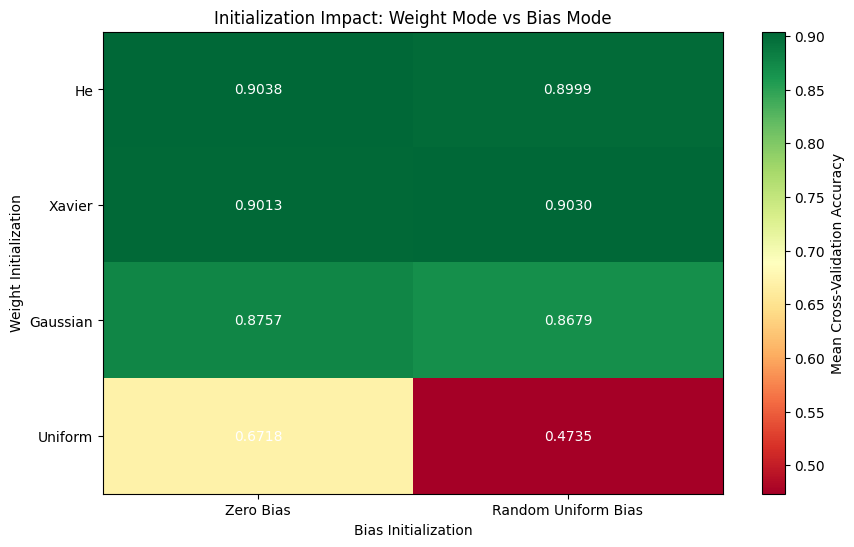

In [ ]:
result_accuracies = np.zeros((4, 2))

# We iterate over all possible weight and bias initialization modes
for weight_mode in [1, 2, 3, 4]: 
    for bias_mode in [0, 1]:

        run_means = []

        # We run the network 10 times and take the mean of the results
        for i in range(10):
            net = Network([
                Linear(10, 32, init_mode_weight=weight_mode, init_mode_bias=bias_mode),
                Activation(),
                Linear(32, 7, init_mode_weight=weight_mode, init_mode_bias=bias_mode)
            ])

            # Due to this step being just to get intuition and rather lengthy, we use only 3 folds and 250 epochs for it to finish faster.
            fold_acc = k_fold_cross_validation(net, features, targets, Loss, k=3, epochs=250)
            fold_mean = np.mean(fold_acc)
            run_means.append(fold_mean)

        result_accuracies[weight_mode-1][bias_mode] = np.mean(run_means)

weight_labels = ["He", "Xavier", "Gaussian", "Uniform"]
bias_labels = ["Zero Bias", "Random Uniform Bias"]

# Heatmap Visualization
plt.figure(figsize=(10, 6))
plt.imshow(result_accuracies, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='Mean Cross-Validation Accuracy')
plt.xticks(ticks=[0, 1], labels=bias_labels)
plt.yticks(ticks=[0, 1, 2, 3], labels=weight_labels)
plt.title("Initialization Impact: Weight Mode vs Bias Mode")
plt.xlabel("Bias Initialization")
plt.ylabel("Weight Initialization")

# Annotate with accuracy values
for i in [0, 1, 2, 3]:
    for j in [0, 1]:
        plt.text(j, i, f'{result_accuracies[i, j]:.4f}', 
                 ha='center', va='center', color='white')

plt.show()

# NOTE: This step takes roughly 3 minutes . You might switch from i in range (10) to just 1 or 2 repetitions per mode for faster results. 

We observe that He and Xavier initialization perform significantly better than Gaussian and Uniform and that results are very similar between those two. Random initialization for bias seems to not influence the accuracy much for He and Xavier. We will further investigate how these two perform with more epochs and better estimate (larger k for k-fold).

In [ ]:
result_accuracies = [0, 0]

# We iterate over all possible weight initialization modes
for weight_mode in [1, 2]: 

        run_means = []

        # We run the network 10 times and take the mean of the results
        for i in range(1):
            net = Network([
                Linear(10, 32, init_mode_weight=weight_mode),
                Activation(),
                Linear(32, 7, init_mode_weight=weight_mode)
            ])

            # We use 10 folds and 1000 epochs for this step
            fold_acc = k_fold_cross_validation(net, features, targets, Loss, k=10, epochs=1000)
            fold_mean = np.mean(fold_acc)
            run_means.append(fold_mean)

        result_accuracies[weight_mode-1]= np.mean(run_means)

print(f"He Initialization Accuracy: {result_accuracies[0]}")
print(f"Xavier Initialization Accuracy: {result_accuracies[1]}")

He Initialization Accuracy: 0.9283173692484725
Xavier Initialization Accuracy: 0.9272977747524351


We see that these two perform very similarly, with He being slightly better.

### 1.4 Optimization

#### Question 11

In [ ]:
# We keep the same architecture and hyperparameters as before and only vary the number of hidden neurons.
# For each size we run k-fold cross-validation multiple times and average the validation accuracies.

hidden_neurons = [7, 10, 15, 20, 30]   # hidden layer sizes to evaluate
k_folds = 5                            # k in k-fold cross-validation
epochs = 500                           # training epochs per fold

mean_accuracies = []
std_accuracies = []

for n_hidden in hidden_neurons:
    run_means = []

    # We run the network 10 times and take the mean of the results
    for i in range(10):
        net = Network([
            Linear(10, n_hidden, init_mode_weight=1),
            Activation(),
            Linear(n_hidden, 7, init_mode_weight=1)
        ])

        # We use 5 folds and 500 epochs for this step
        fold_acc = k_fold_cross_validation(
            net,
            features,
            targets,
            Loss,
            k=k_folds,
            epochs=epochs
        )
        run_means.append(np.mean(fold_acc))

    # Take the mean of the results
    mean_accuracies.append(np.mean(run_means))
    std_accuracies.append(np.std(run_means))

hidden_neurons = np.array(hidden_neurons)
mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(hidden_neurons, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
plt.xlabel('Number of hidden neurons')
plt.ylabel('Mean validation accuracy')
plt.title('Question 11: Performance vs number of hidden neurons')
plt.grid(True)
plt.show()

for n_hidden, mean_acc, std_acc in zip(hidden_neurons, mean_accuracies, std_accuracies):
    print(f'n_hidden = {n_hidden:2d}: mean accuracy = {mean_acc:.4f} ± {std_acc:.4f}')

# NOTE: This cell can take several minutes to run due to the nested loop over hidden sizes, runs and folds.
# You can temporarily reduce the number of runs, k_folds, or epochs while experimenting.

We ran the same network architecture as before but varied only the number of hidden neurons (between 7 and 30), keeping the learning rate, number of epochs, batch size and initialization fixed. For each hidden size, we trained the model multiple times with different random initializations and used the average cross-validation accuracy as our performance measure.

From the plot we see that very small hidden layers achieve lower accuracy, because the model does not have enough capacity to capture the patterns in the data. As we increase the number of hidden neurons, the performance improves and then starts to plateau, with only small gains for the largest hidden sizes and slightly higher variance between runs. This behaviour is consistent with the bias–variance tradeoff, too few neurons lead to underfitting, while very large layers do not significantly improve accuracy and mainly make training slower and a bit less stable.


#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>